# UD5 - Visualización de datos con Python
## Matplotlib vs Seaborn: el mismo gráfico, dos formas
---

In [1]:
# Si no están instaladas, descomenta y ejecuta:
# !pip install matplotlib seaborn pandas numpy

# Importamos las librerías con sus alias estándar.
import matplotlib.pyplot as plt   
import seaborn as sns              
import pandas as pd                
import numpy as np                 

%matplotlib inline

# Opcional: hace que los gráficos se vean más grandes y nítidos
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['figure.dpi'] = 100          

print("Todo listo. Matplotlib versión:", plt.matplotlib.__version__)
print("Seaborn versión:", sns.__version__)

Todo listo. Matplotlib versión: 3.8.0
Seaborn versión: 0.13.0


Dataset de trabajo

Vamos a crear un dataset ficticio de StreamFlow, una plataforma de streaming de música.

Tenemos dos datasets:
- datos_mensuales: métricas agregadas de la plataforma mes a mes.
- usuarios: 500 usuarios individuales con sus datos.

In [2]:
# =============================================
# DATASET 1: Datos mensuales de la plataforma
# =============================================
# En un caso real, lo cargaríamos de un CSV con pd.read_csv('archivo.csv')

datos_mensuales = pd.DataFrame({
    'mes': ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
            'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'],
    'mes_num': range(1, 13),
    
    # Usuarios activos mensuales (MAU) - van creciendo con un bajón en verano
    'mau': [1200000, 1250000, 1310000, 1350000, 1380000, 1340000,
            1290000, 1260000, 1350000, 1420000, 1500000, 1580000],
    
    # Ingresos en miles de euros
    'ingresos_k': [320, 335, 352, 360, 370, 355,
                   338, 325, 358, 385, 410, 468],
    
    # Horas de escucha por usuario (media diaria)
    'horas_escucha': [1.8, 1.9, 2.0, 1.9, 1.8, 1.7,
                      1.6, 1.5, 1.8, 2.0, 2.1, 2.3],
    
    # Tasa de churn (% de usuarios que cancelan)
    'churn_pct': [3.2, 3.0, 2.8, 2.9, 3.1, 3.5,
                  3.8, 4.0, 3.3, 2.7, 2.5, 2.3],
    
    # Tasa de conversión free -> premium (%)
    'conversion_pct': [4.5, 4.7, 5.0, 4.8, 4.6, 4.3,
                       4.1, 3.9, 4.5, 5.1, 5.5, 6.2],
})
datos_mensuales.head()

,mes,mes_num,mau,ingresos_k,horas_escucha,churn_pct,conversion_pct
0,Ene,1,1200000,320,1.8,3.2,4.5
1,Feb,2,1250000,335,1.9,3.0,4.7
2,Mar,3,1310000,352,2.0,2.8,5.0
3,Abr,4,1350000,360,1.9,2.9,4.8
4,May,5,1380000,370,1.8,3.1,4.6


In [3]:
# =============================================
# DATASET 2: Usuarios individuales
# =============================================

np.random.seed(42)

n_usuarios = 500

usuarios = pd.DataFrame({
    'plan': np.random.choice(['Free', 'Premium', 'Familiar', 'Estudiante'], 
                              n_usuarios, 
                              p=[0.40, 0.30, 0.15, 0.15]),
    'edad': np.random.randint(16, 65, n_usuarios),
    
    'horas_mes': np.clip(
        np.random.normal(45, 20, n_usuarios),
        5, 150
    ).round(1),
    
    'pais': np.random.choice(
        ['España', 'México', 'Argentina', 'Colombia', 'Chile', 'Perú'],
        n_usuarios,
        p=[0.30, 0.25, 0.15, 0.13, 0.10, 0.07]
    ),
    'playlists_creadas': np.random.poisson(5, n_usuarios),
})

usuarios.loc[usuarios['plan'] == 'Premium', 'horas_mes'] *= 1.6
usuarios.loc[usuarios['plan'] == 'Free', 'horas_mes'] *= 0.7
usuarios['horas_mes'] = usuarios['horas_mes'].round(1)

# Añadimos gasto mensual según plan
usuarios['gasto_mensual'] = usuarios['plan'].map({
    'Free': 0, 'Premium': 9.99, 'Familiar': 14.99, 'Estudiante': 4.99
})

usuarios.head(10)

,plan,edad,horas_mes,pais,playlists_creadas,gasto_mensual
0,Free,32,13.4,Colombia,6,0.00
1,Estudiante,24,19.1,Colombia,2,4.99
2,Familiar,48,38.3,Colombia,7,14.99
3,Premium,35,125.4,México,4,9.99
4,Free,28,27.9,Colombia,4,0.00
5,Free,43,10.4,España,4,0.00
6,Free,63,28.1,México,2,0.00
7,Estudiante,44,39.5,España,6,4.99
8,Premium,28,8.0,México,6,9.99
9,Familiar,61,43.9,México,6,14.99


In [4]:
# Resumen rápido del dataset
usuarios.describe()

,edad,horas_mes,playlists_creadas,gasto_mensual
count,500.0000,500.00000,500.000000,500.000000
mean,39.6560,49.15060,4.980000,5.734140
std,14.3918,27.32624,2.247154,5.564785
min,16.0000,3.50000,0.000000,0.000000
25%,26.0000,29.50000,3.000000,0.000000
50%,40.0000,44.20000,5.000000,4.990000
75%,52.0000,65.82500,6.000000,9.990000
max,64.0000,136.30000,12.000000,14.990000


In [5]:
# ¿Cuántos usuarios hay de cada plan?
usuarios['plan'].value_counts()

plan
Free          207
Premium       139
Estudiante     83
Familiar       71
Name: count, dtype: int64

In [6]:
# PALETA DE COLORES COMÚN
colores = ['#378ADD', '#1D9E75', '#EF9F27', '#D85A30']

# Para Seaborn, activamos un estilo base limpio
sns.set_style('whitegrid')

**1. Gráfico de líneas — Evolución temporal**

El gráfico más básico. Perfecto para mostrar cómo cambia un valor a lo largo del tiempo.

Pregunta que responde: ¿Cómo han evolucionado los ingresos de StreamFlow mes a mes?

**Con Matplotlib**

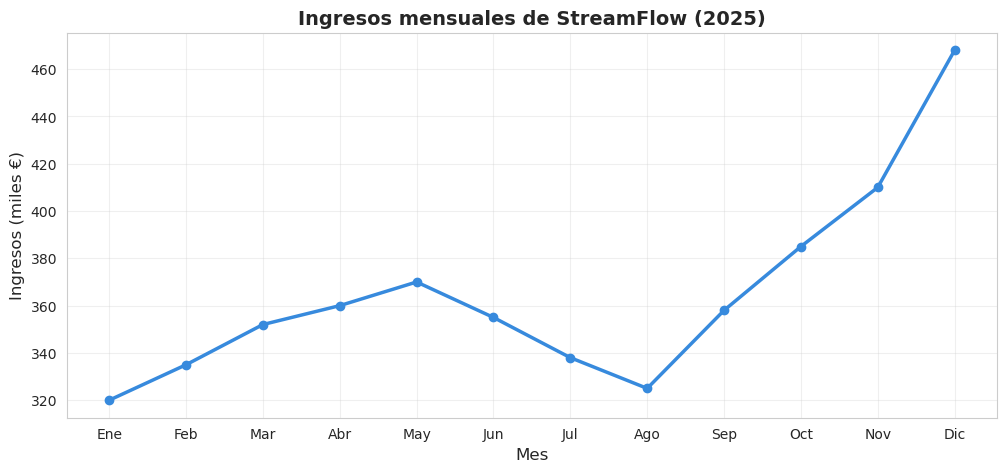

In [7]:
# === LÍNEAS CON MATPLOTLIB ===

plt.figure(figsize=(12, 5))

plt.plot(
    datos_mensuales['mes'],          
    datos_mensuales['ingresos_k'],   
    color='#378ADD',                 
    linewidth=2.5,                   
    marker='o',                      
    markersize=6,                    
    linestyle='-',                  
)

# Título y etiquetas:
plt.title('Ingresos mensuales de StreamFlow (2025)', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ingresos (miles €)', fontsize=12)

# Cuadrícula suave para facilitar la lectura
plt.grid(True, alpha=0.3)

plt.show()

**Con Seaborn**

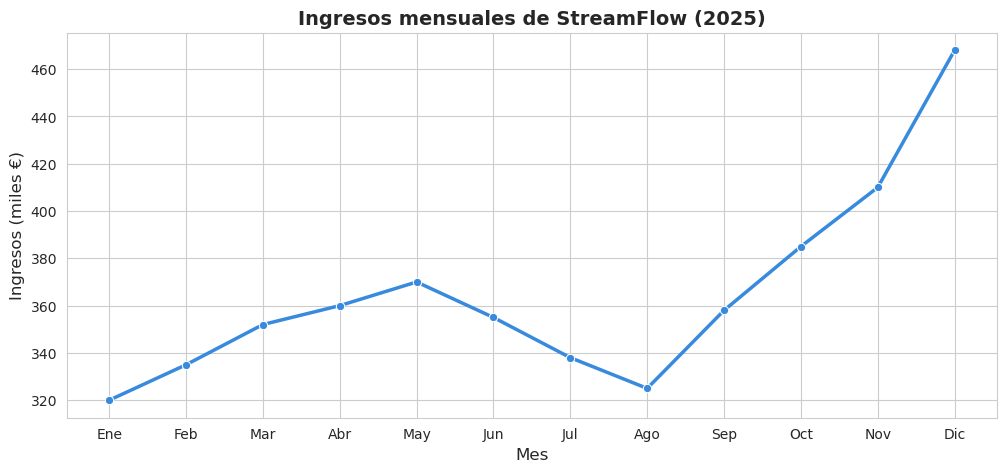

In [8]:
# === LÍNEAS CON SEABORN ===

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=datos_mensuales,      
    x='mes',                   
    y='ingresos_k',            
    color='#378ADD',           
    linewidth=2.5,             
    marker='o',                
    linestyle='-'   
)

# Los títulos y etiquetas siguen usando plt (seaborn no reemplaza todo)
plt.title('Ingresos mensuales de StreamFlow (2025)', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ingresos (miles €)', fontsize=12)

plt.show()

**Varias líneas en el mismo gráfico**

Comparamos ingresos 2025 vs 2024. En matplotlib y seaborn se hace de forma similar: cada línea es una llamada adicional.

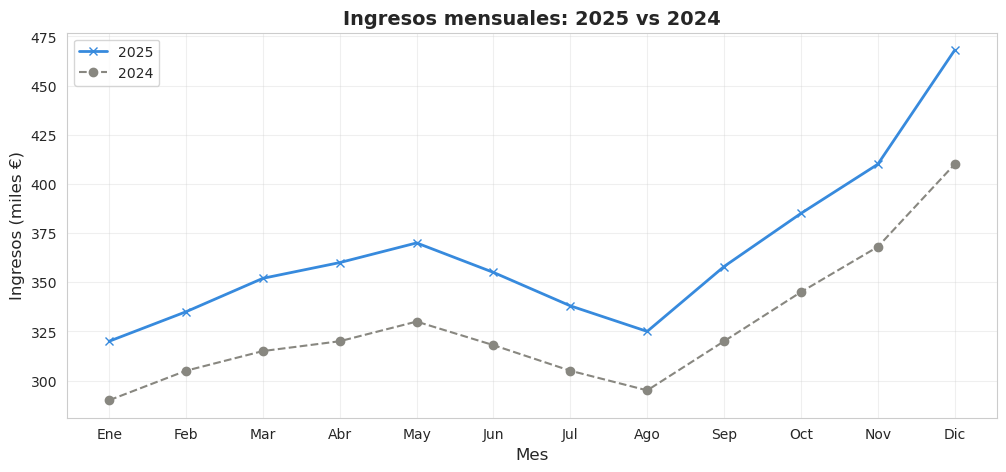

In [9]:
# === VARIAS LÍNEAS CON MATPLOTLIB ===
# Cada plt.plot() añade una línea al mismo gráfico

# Inventamos datos del año anterior para comparar
ingresos_2024 = [290, 305, 315, 320, 330, 318, 305, 295, 320, 345, 368, 410]

plt.figure(figsize=(12, 5))

# Primera línea: 2025
plt.plot(datos_mensuales['mes'], datos_mensuales['ingresos_k'], 
         color='#378ADD', marker='x', linewidth=2, label='2025')

# Segunda línea: 2024
plt.plot(datos_mensuales['mes'], ingresos_2024, 
         color='#888780', marker='o', linewidth=1.5, linestyle='--', label='2024')

plt.title('Ingresos mensuales: 2025 vs 2024', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ingresos (miles €)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.legend(loc='upper left', fontsize=10)

plt.show()

**2. Gráfico de barras — Comparar cantidades**

Para comparar valores entre categorías.

Pregunta que responde: ¿De qué país son nuestros usuarios?

**Con Matplotlib**

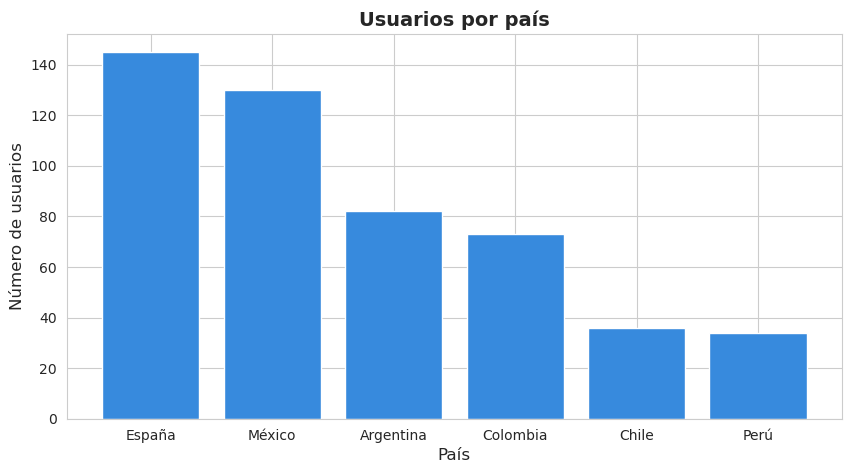

In [10]:
# === BARRAS CON MATPLOTLIB ===
# Primero necesitamos CALCULAR los datos nosotros mismos
usuarios_pais = usuarios['pais'].value_counts()

plt.figure(figsize=(10, 5))

plt.bar(
    usuarios_pais.index,      
    usuarios_pais.values,     
    color='#378ADD',          
    edgecolor='white'         
)

plt.title('Usuarios por país', fontsize=14, fontweight='bold')
plt.xlabel('País', fontsize=12)
plt.ylabel('Número de usuarios', fontsize=12)

plt.show()

**Con Seaborn**

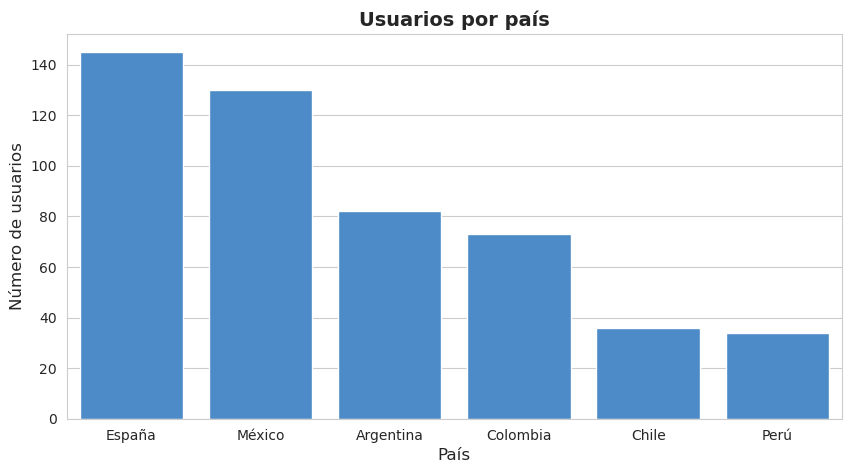

In [11]:
# === BARRAS CON SEABORN (countplot) ===

plt.figure(figsize=(10, 5))

sns.countplot(
    data=usuarios,                                  
    x='pais',                                       
    color='#378ADD',                                
    order=usuarios['pais'].value_counts().index      
)

plt.title('Usuarios por país', fontsize=14, fontweight='bold')
plt.xlabel('País', fontsize=12)
plt.ylabel('Número de usuarios', fontsize=12)

plt.show()

**Barras horizontales**

Mejor cuando los nombres de las categorías son largos. Veamos las dos formas.

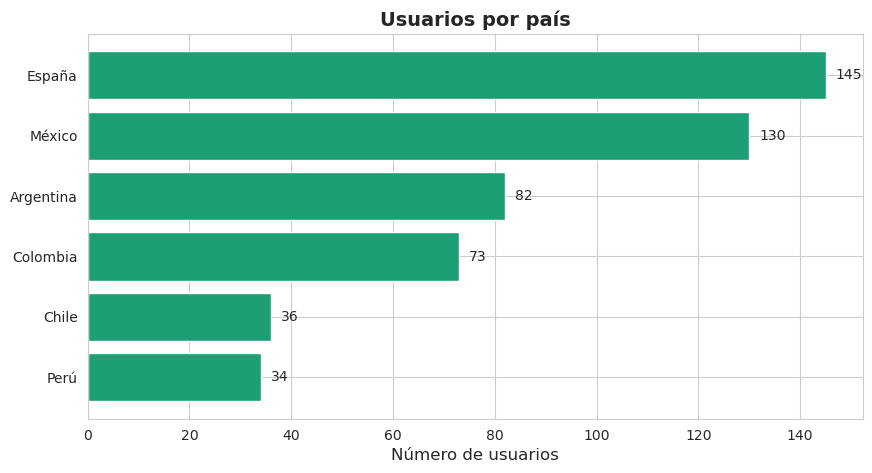

In [12]:
# === BARRAS HORIZONTALES CON MATPLOTLIB ===

usuarios_pais_sorted = usuarios['pais'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 5))

plt.barh(
    usuarios_pais_sorted.index,     
    usuarios_pais_sorted.values,    
    color='#1D9E75',                
    edgecolor='white'
)

# Añadimos el valor al final de cada barra
for i, v in enumerate(usuarios_pais_sorted.values):
    plt.text(v + 2, i, str(v), va='center', fontsize=10)

plt.title('Usuarios por país', fontsize=14, fontweight='bold')
plt.xlabel('Número de usuarios', fontsize=12)

plt.show()

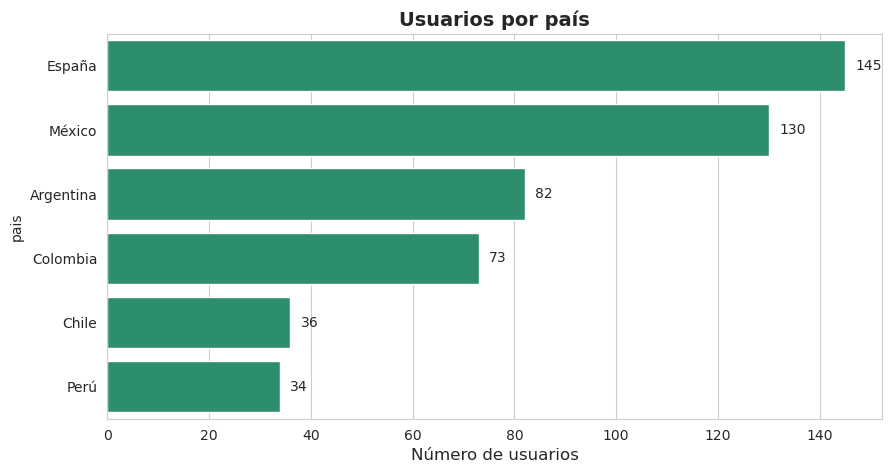

In [13]:
# === BARRAS HORIZONTALES CON SEABORN ===
# En seaborn, para hacer barras horizontales simplemente
# intercambiamos x e y: ponemos la categoría en y

usuarios_pais_sorted = usuarios['pais'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 5))

sns.countplot(
    data=usuarios,
    y='pais',
    color='#1D9E75',
    order=usuarios_pais_sorted.index
)

for i, v in enumerate(usuarios_pais_sorted.values):
    plt.text(v + 2, i, str(v), va='center', fontsize=10)

plt.gca().invert_yaxis()   # Invierte el eje Y para que el mayor quede arriba

plt.title('Usuarios por país', fontsize=14, fontweight='bold')
plt.xlabel('Número de usuarios', fontsize=12)

plt.show()

# DIFERENCIA: en seaborn basta con cambiar x= por y=
# En matplotlib hay que cambiar de plt.bar() a plt.barh()

**Barras agrupadas (por país y plan)**

Pregunta que responde: ¿Cuántos usuarios hay de cada plan en cada país?

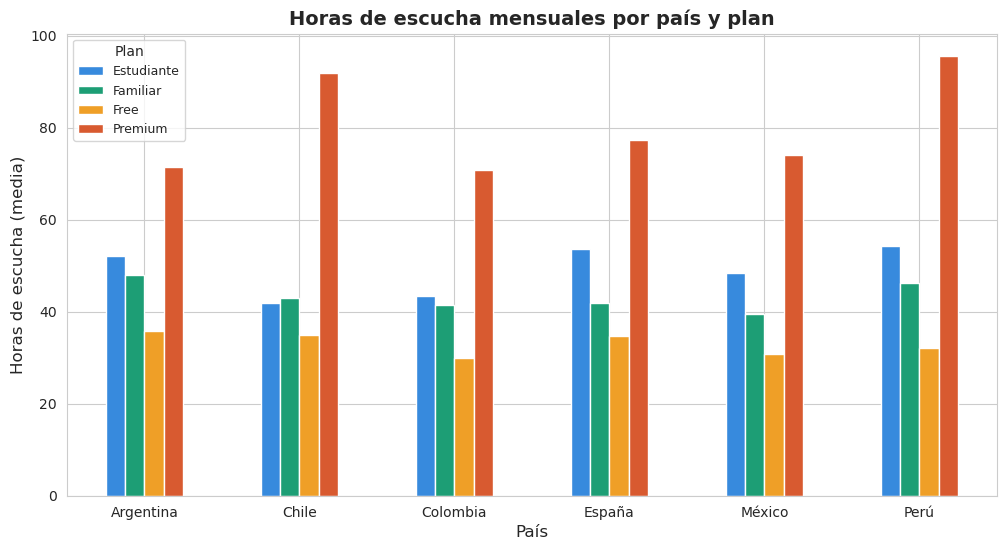

In [14]:
# === BARRAS AGRUPADAS CON MATPLOTLIB ===
# Con matplotlib esto es bastante laborioso.
# Necesitamos calcular la tabla cruzada nosotros y usar el método .plot() de Pandas
# (que internamente usa matplotlib)

# Calculamos horas medias por país y plan
horas_plan_pais = usuarios.groupby(['pais', 'plan'])['horas_mes'].mean().unstack()


horas_plan_pais.plot(
    kind='bar',                                         
    figsize=(12, 6),                                     
    color=colores,                                      
    edgecolor='white',
    width=0.5                                           
)

plt.title('Horas de escucha mensuales por país y plan', fontsize=14, fontweight='bold')
plt.xlabel('País', fontsize=12)
plt.ylabel('Horas de escucha (media)', fontsize=12)
plt.legend(title='Plan', fontsize=9)

plt.xticks(rotation=0)
plt.show()

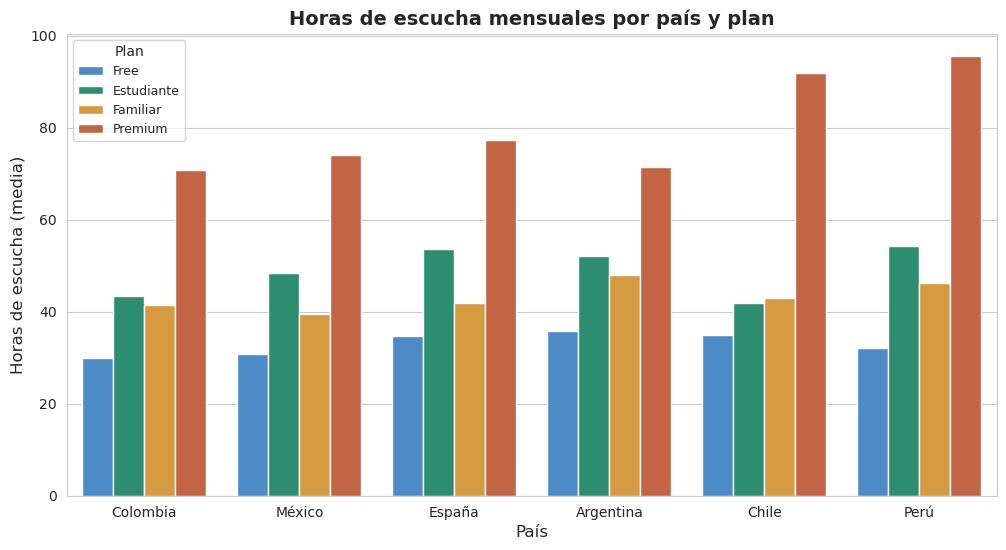

In [15]:
# === BARRAS AGRUPADAS CON SEABORN ===
# Le decimos "agrupa por país y colorea por plan" y él se encarga.

plt.figure(figsize=(12, 6))

sns.barplot(
    data=usuarios,                    
    x='pais',                         
    y='horas_mes',                    
    hue='plan',                      
    palette=colores,             
    errorbar=None                      
)

plt.title('Horas de escucha mensuales por país y plan', fontsize=14, fontweight='bold')
plt.xlabel('País', fontsize=12)
plt.ylabel('Horas de escucha (media)', fontsize=12)
plt.legend(title='Plan', fontsize=9)

plt.show()

# DIFERENCIA:
# - Matplotlib: groupby + unstack + .plot(kind='bar') + configurar colores a mano
# - Seaborn: una llamada a sns.barplot() con hue='plan' y ya está

**3. Histograma — Distribución de una variable**

El histograma divide una variable numérica en rangos ("bins") y cuenta cuántos valores caen en cada rango.

Pregunta que responde: ¿Cómo se distribuyen las horas de escucha entre nuestros usuarios?

**Con Matplotlib**

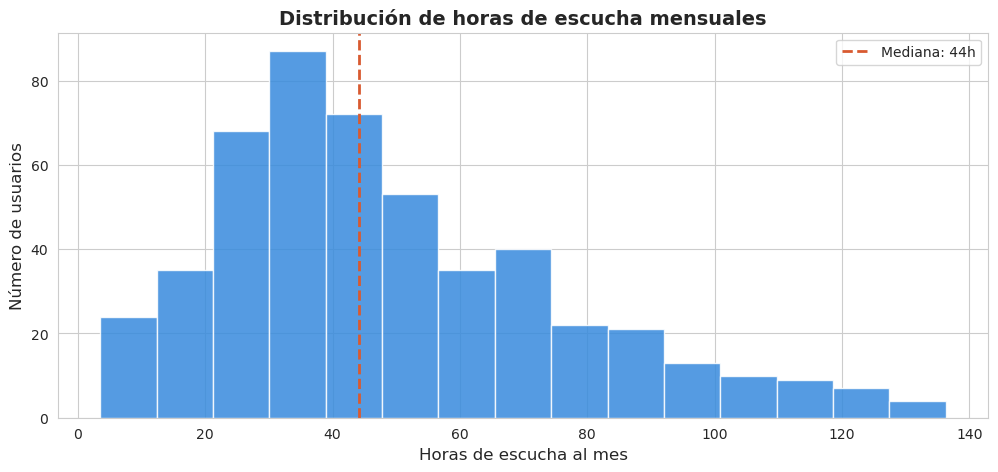

In [16]:
# === HISTOGRAMA CON MATPLOTLIB ===

plt.figure(figsize=(12, 5))

plt.hist(
    usuarios['horas_mes'],       
    bins=15,                     
    color='#378ADD',
    edgecolor='white',
    alpha=0.85                   
)

# Línea vertical con la mediana
mediana = usuarios['horas_mes'].median()
plt.axvline(
    mediana,                     
    color='#D85A30',             
    linewidth=2,
    linestyle='--',              
    label=f'Mediana: {mediana:.0f}h' 
)

plt.title('Distribución de horas de escucha mensuales', fontsize=14, fontweight='bold')
plt.xlabel('Horas de escucha al mes', fontsize=12)
plt.ylabel('Número de usuarios', fontsize=12)
plt.legend(fontsize=10)

plt.show()

**Con Seaborn**

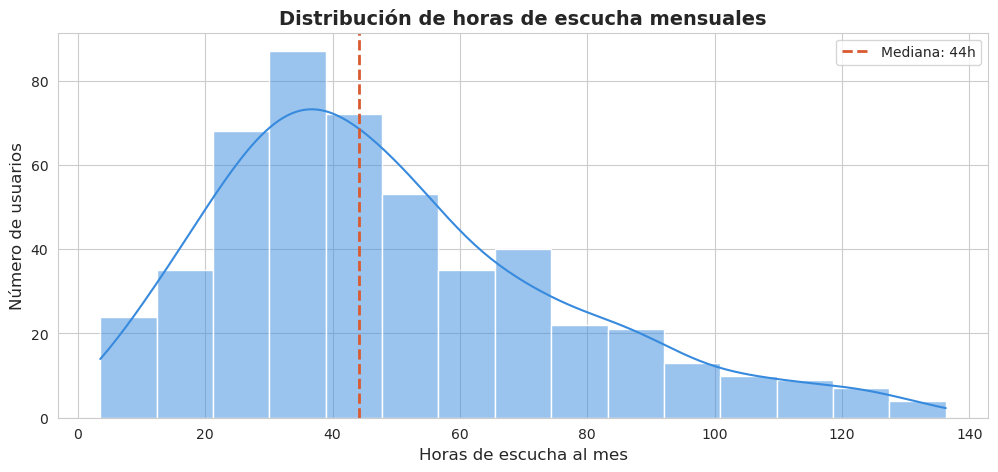

In [17]:
# === HISTOGRAMA CON SEABORN ===
# sns.histplot hace lo mismo pero con mejor estilo por defecto
# y además puede superponer una curva de densidad (kde)

plt.figure(figsize=(12, 5))

sns.histplot(
    data=usuarios,               
    x='horas_mes',               
    bins=15,                     
    color='#378ADD',
    edgecolor='white',
    kde=True,                   # Kernel Density Estimate
                                 
)

# La línea de la mediana la seguimos haciendo con plt (seaborn no tiene función para esto)
mediana = usuarios['horas_mes'].median()
plt.axvline(mediana, color='#D85A30', linewidth=2, linestyle='--', 
            label=f'Mediana: {mediana:.0f}h')

plt.title('Distribución de horas de escucha mensuales', fontsize=14, fontweight='bold')
plt.xlabel('Horas de escucha al mes', fontsize=12)
plt.ylabel('Número de usuarios', fontsize=12)
plt.legend(fontsize=10)

plt.show()

# DIFERENCIA: seaborn añade la curva kde con un simple kde=True.
# En matplotlib, dibujar esa curva a mano sería bastante más código.

**4. Gráfico de dispersión (scatter) — Relaciones entre variables**

Pregunta que responde: ¿Los usuarios que crean más playlists escuchan más horas?

**Con Matplotlib**

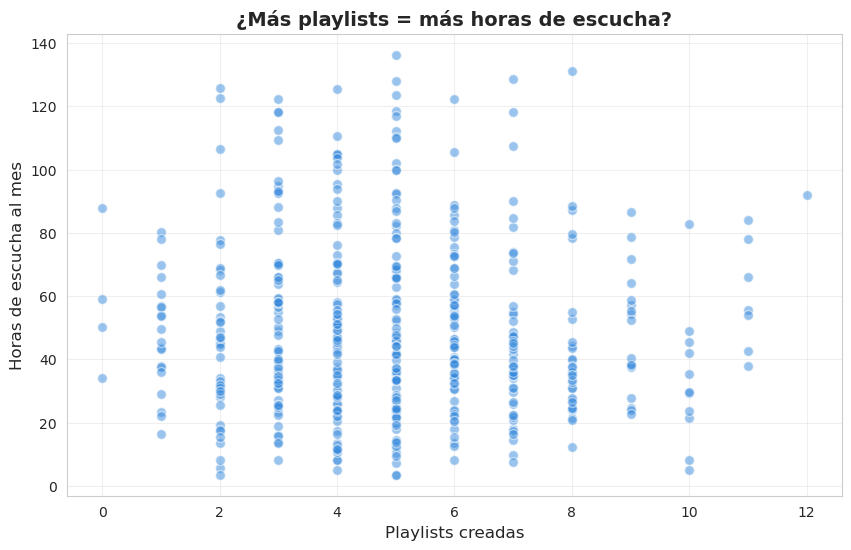

In [18]:
# === SCATTER CON MATPLOTLIB ===

plt.figure(figsize=(10, 6))

plt.scatter(
    usuarios['playlists_creadas'],  
    usuarios['horas_mes'],          
    color='#378ADD',
    alpha=0.5,                      
    edgecolors='white',             
    s=50                            
)

plt.title('¿Más playlists = más horas de escucha?', fontsize=14, fontweight='bold')
plt.xlabel('Playlists creadas', fontsize=12)
plt.ylabel('Horas de escucha al mes', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

**Con Seaborn**

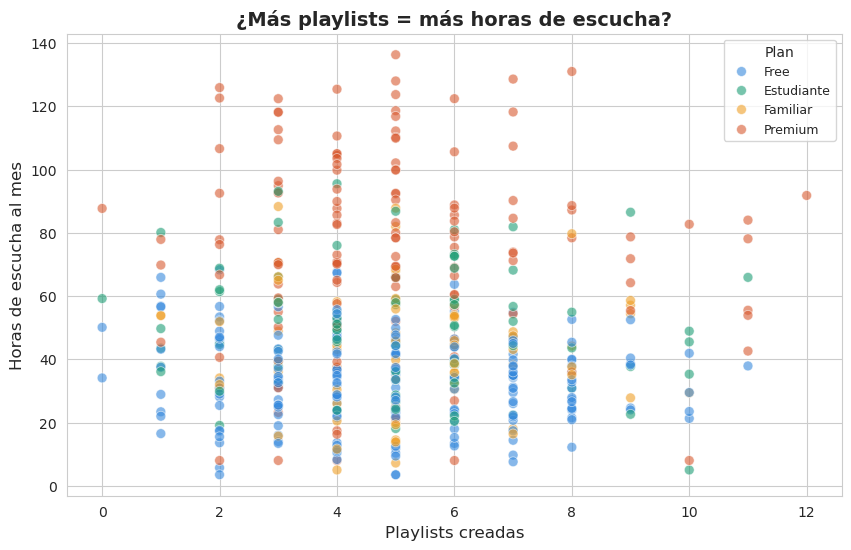

In [19]:
# === SCATTER CON SEABORN ===
# Aquí seaborn aporta algo muy útil: colorear los puntos por una categoría
# con hue='plan', sin tener que hacer nada manual.

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=usuarios,                     
    x='playlists_creadas',            
    y='horas_mes',                     
    hue='plan',                        
    palette=colores[:4],               
    alpha=0.6,                         
    s=50,                              
)

plt.title('¿Más playlists = más horas de escucha?', fontsize=14, fontweight='bold')
plt.xlabel('Playlists creadas', fontsize=12)
plt.ylabel('Horas de escucha al mes', fontsize=12)
plt.legend(title='Plan', fontsize=9)

plt.show()

# En matplotlib, para hacer esto tendríamos que hacer un bucle:
# pintar los Free de un color, los Premium de otro, etc. Bastante más código.

**5. Box plot — Distribución por categoría**

El box plot muestra la mediana, cuartiles y outliers de una variable, separando por categorías.

Pregunta que responde: ¿Cuántas horas escuchan los usuarios según su plan?

**Con Matplotlib**

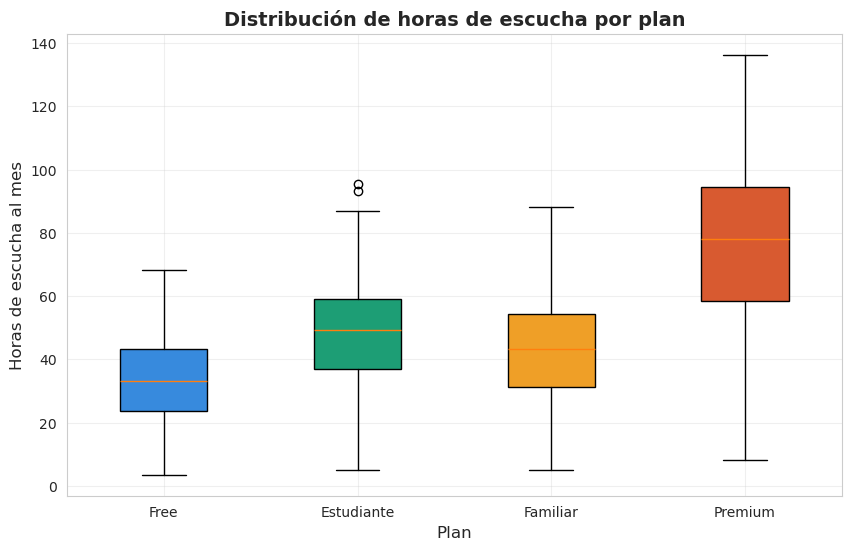

In [20]:
# === BOX PLOT CON MATPLOTLIB ===

# Definimos el orden que queremos
orden_planes = ['Free', 'Estudiante', 'Familiar', 'Premium']

# Creamos una lista con las horas de cada plan por separado
# Es decir: [[horas de Free], [horas de Estudiante], [horas de Familiar], [horas de Premium]]
datos_por_plan = [usuarios[usuarios['plan'] == plan]['horas_mes'] for plan in orden_planes]

plt.figure(figsize=(10, 6))

# plt.boxplot recibe una lista de arrays
bp = plt.boxplot(
    datos_por_plan,
    labels=orden_planes,          
    patch_artist=True,            # Necesario para poder rellenar las cajas con color
)

# Para colorear cada caja, hay que recorrerlas una a una
for i, box in enumerate(bp['boxes']):
    box.set_facecolor(colores[i])     # Color de relleno
    box.set_edgecolor('black')        # Color del borde

plt.title('Distribución de horas de escucha por plan', fontsize=14, fontweight='bold')
plt.xlabel('Plan', fontsize=12)
plt.ylabel('Horas de escucha al mes', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

# Hemos necesitado:
# 1. Separar los datos a mano por categoría
# 2. patch_artist=True para poder colorear
# 3. Un bucle para asignar colores a cada caja

**Con Seaborn**

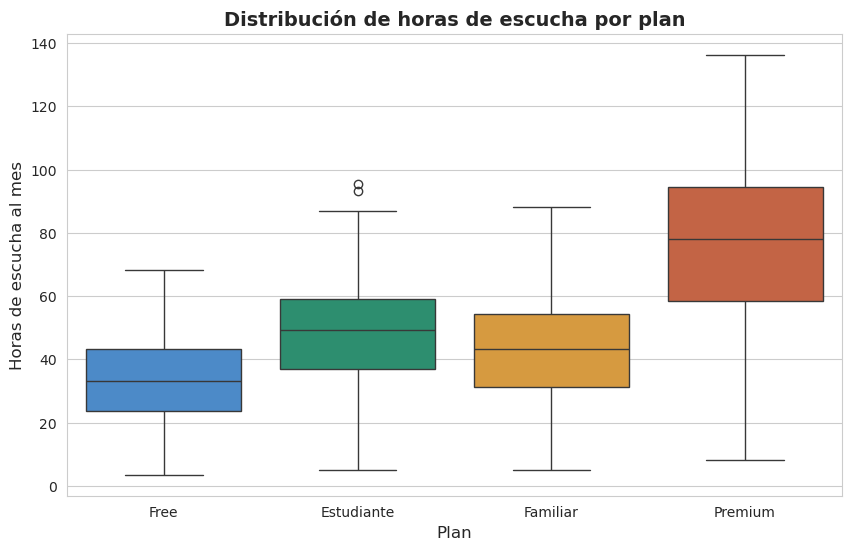

In [21]:
# === BOX PLOT CON SEABORN ===
# Aquí está la diferencia más clara de todas hasta ahora.
# Seaborn hace todo lo que hicimos arriba en una sola llamada.

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=usuarios,                                        
    x='plan',                                             
    y='horas_mes',                                        
    hue='plan',                                           
    palette=colores[:4],                                  
    order=['Free', 'Estudiante', 'Familiar', 'Premium']
)

plt.title('Distribución de horas de escucha por plan', fontsize=14, fontweight='bold')
plt.xlabel('Plan', fontsize=12)
plt.ylabel('Horas de escucha al mes', fontsize=12)

plt.show()

# Es el mismo gráfico, pero sin separar datos, sin patch_artist,
# sin bucle para colores. Le pasas el DataFrame y los nombres de las columnas.

**6. Gráfico de tarta — Proporciones**

Para mostrar qué porcentaje representa cada parte del total. Solo funciona bien con pocas categorías (4-5 máximo).

Pregunta que responde: ¿Qué proporción de usuarios tiene cada plan?

Este gráfico se hace prácticamente igual en ambas librerías. Seaborn no tiene un gráfico de tarta propio, así que siempre se usa matplotlib.

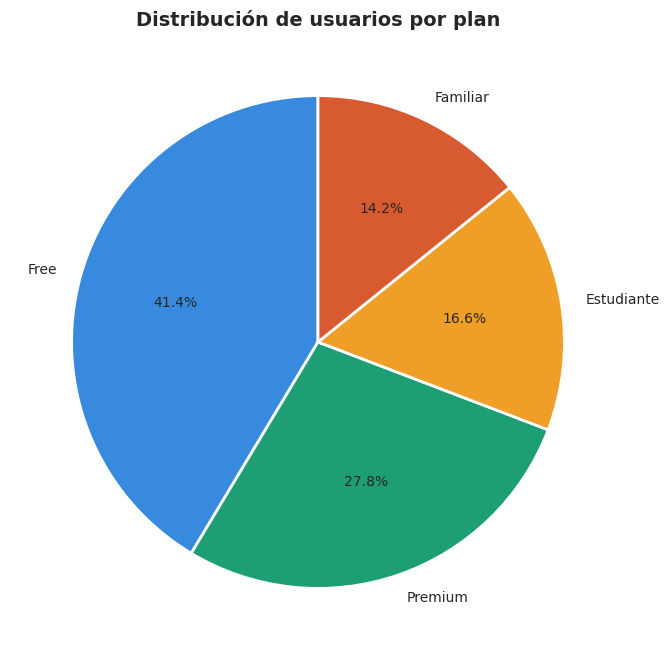

In [22]:
# === GRÁFICO DE TARTA (solo matplotlib) ===

plan_counts = usuarios['plan'].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    plan_counts.values,           
    labels=plan_counts.index,     
    colors=colores[:4],           
    autopct='%1.1f%%',            
    startangle=90,                
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}  
)

plt.title('Distribución de usuarios por plan', fontsize=14, fontweight='bold')

plt.show()

**7. Subplots — Varios gráficos en una figura**

A veces queremos juntar varios gráficos en una sola imagen (como un mini-dashboard).

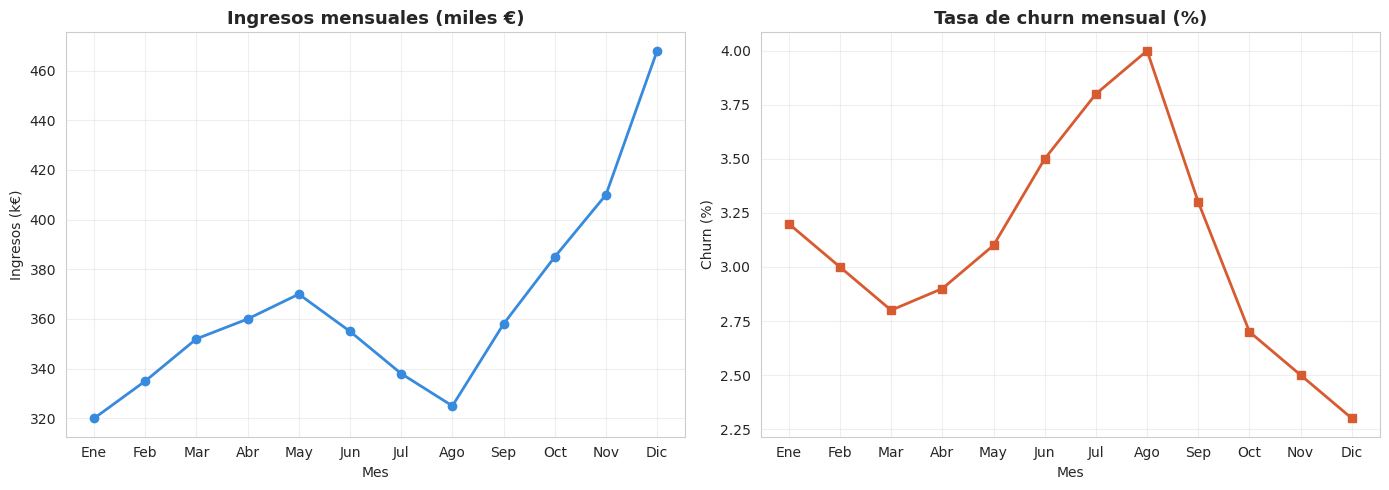

In [23]:
# === SUBPLOTS: 2 GRÁFICOS LADO A LADO ===

# plt.subplots(filas, columnas) crea la cuadrícula
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico izquierdo: ingresos ---
# Ahora usamos ax1.plot() en lugar de plt.plot()
ax1.plot(datos_mensuales['mes'], datos_mensuales['ingresos_k'], 
         color='#378ADD', marker='o', linewidth=2)
ax1.set_title('Ingresos mensuales (miles €)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Mes')               # con ax se usa set_xlabel, no xlabel
ax1.set_ylabel('Ingresos (k€)')     # con ax se usa set_ylabel, no ylabel
ax1.grid(True, alpha=0.3)

# --- Gráfico derecho: churn ---
ax2.plot(datos_mensuales['mes'], datos_mensuales['churn_pct'], 
         color='#D85A30', marker='s', linewidth=2)
ax2.set_title('Tasa de churn mensual (%)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Mes')
ax2.set_ylabel('Churn (%)')
ax2.grid(True, alpha=0.3)

# tight_layout evita que los gráficos se solapen entre sí
plt.tight_layout()
plt.show()

---

## 9. Guardar un gráfico como imagen

Para incluir un gráfico en un informe o presentación, necesitas guardarlo como archivo.

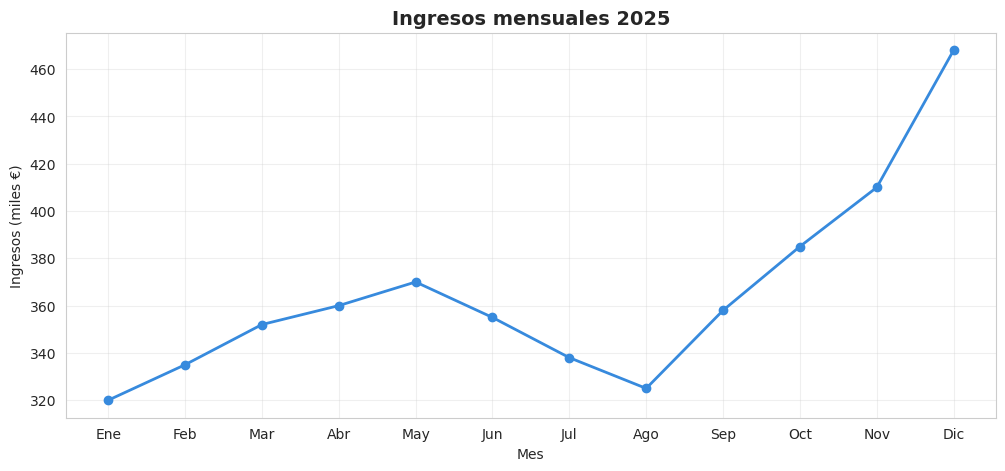

Gráfico guardado como 'ingresos_2025.png'


In [24]:
# === GUARDAR GRÁFICO COMO ARCHIVO ===

# Primero creamos el gráfico (da igual si es matplotlib o seaborn)
plt.figure(figsize=(12, 5))
plt.plot(datos_mensuales['mes'], datos_mensuales['ingresos_k'], 
         color='#378ADD', marker='o', linewidth=2)
plt.title('Ingresos mensuales 2025', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Ingresos (miles €)')
plt.grid(True, alpha=0.3)

# savefig() ANTES de show()
# Si lo pones después, guarda una imagen en blanco.
# dpi=150: buena calidad para presentaciones
plt.savefig('ingresos_2025.png', dpi=150, bbox_inches='tight')

plt.show()
print("Gráfico guardado como 'ingresos_2025.png'")

**9. Lo que Seaborn hace y Matplotlib no (fácilmente)**

Hay gráficos donde seaborn no es solo "más cómodo", sino que hace cosas que en matplotlib serían muy difíciles. El heatmap es un buen ejemplo.

**Heatmap — Mapa de calor**

Perfecto para visualizar matrices de datos. Muy útil para:
- Tablas cruzadas (por ejemplo: horas medias por país y plan)
- Matrices de correlación (¿qué variables están relacionadas?)

In [25]:
# === HEATMAP: tabla cruzada ===
# ¿Cuántas horas de media escuchan los usuarios según su país y plan?

# pivot_table crea una tabla cruzada:
tabla_cruzada = usuarios.pivot_table(
    values='horas_mes',    
    index='pais',          
    columns='plan',        
    aggfunc='mean'        
).round(1)                 

# Veamos la tabla antes de hacer la gráfica
print("Tabla cruzada (horas medias):")
print(tabla_cruzada)
print()

Tabla cruzada (horas medias):
plan       Estudiante  Familiar  Free  Premium
pais                                          
Argentina        52.2      48.1  35.8     71.3
Chile            41.8      43.0  35.0     91.8
Colombia         43.3      41.5  29.9     70.8
España           53.6      41.9  34.6     77.3
México           48.4      39.4  30.7     74.1
Perú             54.3      46.1  32.0     95.6



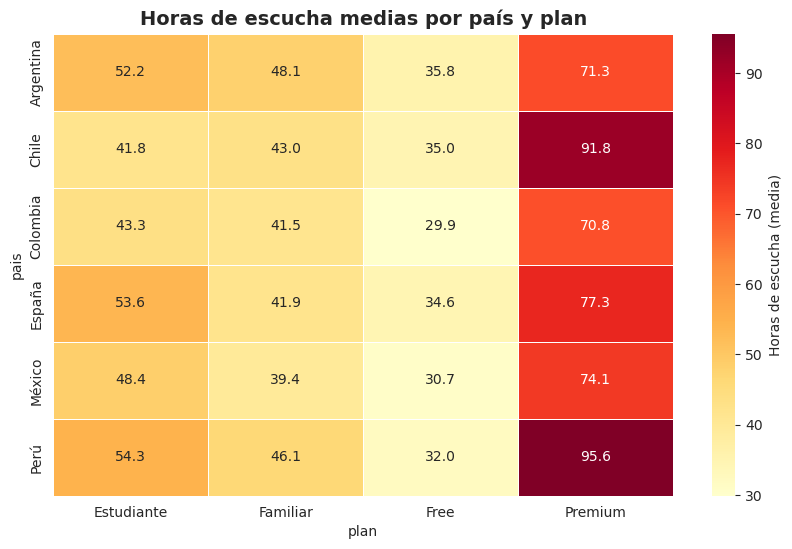

In [26]:
# Ahora la visualizamos como heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    tabla_cruzada,
    annot=True,              
    fmt='.1f',               
    cmap='YlOrRd',           # Paleta: amarillo-naranja-rojo (de menos a más)
    linewidths=0.5,          
    linecolor='white',       
    cbar_kws={'label': 'Horas de escucha (media)'}  
)

plt.title('Horas de escucha medias por país y plan', fontsize=14, fontweight='bold')

plt.show()

# Esto en matplotlib puro sería plt.imshow() + bucle para poner los números
# + configurar colores manualmente. Bastante más trabajo.

**Heatmap de correlaciones**

¿Qué variables numéricas están relacionadas entre sí?

El coeficiente de correlación de Pearson mide la relación lineal entre dos variables:
- Cercano a 1: cuando una sube, la otra también (correlación positiva)
- Cercano a -1: cuando una sube, la otra baja (correlación negativa)
- Cercano a 0: no hay relación lineal

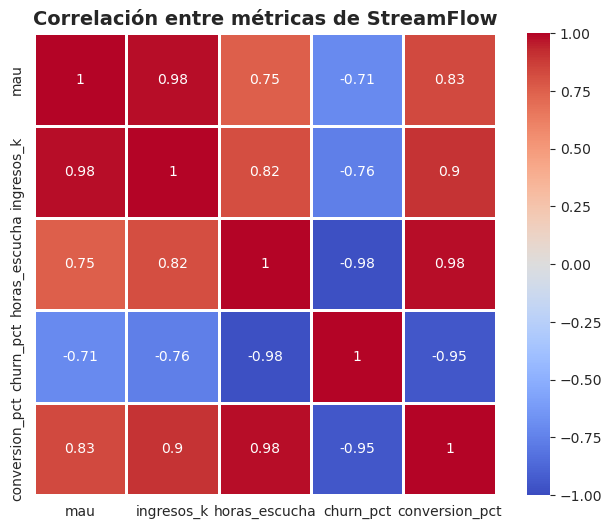

In [27]:
# === HEATMAP DE CORRELACIONES ===

# .corr() calcula la correlación entre todas las columnas numéricas
correlaciones = datos_mensuales[['mau', 'ingresos_k', 'horas_escucha', 
                                  'churn_pct', 'conversion_pct']].corr().round(2)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlaciones,
    annot=True,              
    cmap='coolwarm',         # Azul = correlación negativa, rojo = positiva
    center=0,                # Centra la paleta en 0 (blanco = sin correlación)
    vmin=-1, vmax=1,        
    linewidths=1,
    linecolor='white',
    square=True              # Celdas cuadradas (más estético)
)

plt.title('Correlación entre métricas de StreamFlow', fontsize=14, fontweight='bold')

plt.show()
